<a href="https://colab.research.google.com/github/iamrealllytrying/fechamento-contabil-agentes/blob/main/codigo_otimizacao_fechamento_contabil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import statistics
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# -------------------------
# Classe base dos agentes
# -------------------------
class Agente:
    def __init__(self, nome, atraso, qualidade, integracao):
        self.nome = nome
        self.atraso = atraso              # escala 0 a 10
        self.qualidade = qualidade        # escala 0 a 10
        self.integracao = integracao      # escala 0 a 10

    def atualizar(self, variacao=1):
        """Simula pequenas variações ao longo do tempo."""
        self.atraso = max(0, min(10, self.atraso + random.randint(-variacao, variacao)))
        self.qualidade = max(0, min(10, self.qualidade + random.randint(-variacao, variacao)))
        self.integracao = max(0, min(10, self.integracao + random.randint(-variacao, variacao)))


# -------------------------
# Classe da Contabilidade
# -------------------------
class Contabilidade:
    def __init__(self):
        self.tempo_fechamento = 0
        self.retrabalho = 0
        self.confiabilidade = 10

    def processar(self, logistica, faturamento, tesouraria, ti):
        """
        Regras simplificadas:
        - atrasos aumentam o tempo
        - baixa qualidade aumenta retrabalho
        - baixa integração aumenta retrabalho e reduz confiabilidade
        """

        impacto_atraso = (
            logistica.atraso +
            faturamento.atraso +
            tesouraria.atraso +
            ti.atraso
        )

        impacto_qualidade = (
            (10 - logistica.qualidade) +
            (10 - faturamento.qualidade) +
            (10 - tesouraria.qualidade)
        )

        impacto_integracao = (
            (10 - logistica.integracao) +
            (10 - faturamento.integracao) +
            (10 - tesouraria.integracao) +
            (10 - ti.integracao)
        )

        self.retrabalho = impacto_qualidade + impacto_integracao
        self.tempo_fechamento = 5 + impacto_atraso + self.retrabalho

        penalidade = (impacto_qualidade * 0.3) + (impacto_integracao * 0.2)
        self.confiabilidade = max(0, 10 - penalidade)


# -------------------------
# Criação dos cenários
# -------------------------
def criar_cenario(nome_cenario):
    if nome_cenario == "baixa_integracao":
        logistica = Agente("Logística", atraso=4, qualidade=7, integracao=3)
        faturamento = Agente("Faturamento", atraso=3, qualidade=7, integracao=4)
        tesouraria = Agente("Tesouraria", atraso=4, qualidade=6, integracao=3)
        ti = Agente("TI", atraso=2, qualidade=8, integracao=2)

    elif nome_cenario == "alta_integracao":
        logistica = Agente("Logística", atraso=2, qualidade=8, integracao=8)
        faturamento = Agente("Faturamento", atraso=2, qualidade=8, integracao=8)
        tesouraria = Agente("Tesouraria", atraso=2, qualidade=8, integracao=8)
        ti = Agente("TI", atraso=1, qualidade=9, integracao=9)

    elif nome_cenario == "atrasos_frequentes":
        logistica = Agente("Logística", atraso=7, qualidade=7, integracao=6)
        faturamento = Agente("Faturamento", atraso=6, qualidade=7, integracao=6)
        tesouraria = Agente("Tesouraria", atraso=7, qualidade=6, integracao=5)
        ti = Agente("TI", atraso=4, qualidade=8, integracao=7)

    elif nome_cenario == "melhor_colaboracao":
        logistica = Agente("Logística", atraso=2, qualidade=9, integracao=8)
        faturamento = Agente("Faturamento", atraso=2, qualidade=9, integracao=8)
        tesouraria = Agente("Tesouraria", atraso=2, qualidade=8, integracao=8)
        ti = Agente("TI", atraso=1, qualidade=9, integracao=9)

    else:
        raise ValueError("Cenário não reconhecido.")

    return logistica, faturamento, tesouraria, ti


# -------------------------
# Simulação
# -------------------------
def simular(cenario, ciclos=20, seed=42):
    random.seed(seed)

    logistica, faturamento, tesouraria, ti = criar_cenario(cenario)
    contabilidade = Contabilidade()

    historico_tempo = []
    historico_retrabalho = []
    historico_confiabilidade = []

    for _ in range(ciclos):
        logistica.atualizar()
        faturamento.atualizar()
        tesouraria.atualizar()
        ti.atualizar()

        contabilidade.processar(logistica, faturamento, tesouraria, ti)

        historico_tempo.append(contabilidade.tempo_fechamento)
        historico_retrabalho.append(contabilidade.retrabalho)
        historico_confiabilidade.append(contabilidade.confiabilidade)

    return {
        "tempo": historico_tempo,
        "retrabalho": historico_retrabalho,
        "confiabilidade": historico_confiabilidade
    }


# -------------------------
# Resumo estatístico
# -------------------------
def resumir_resultados(resultados):
    resumo = {
        "tempo_medio": round(statistics.mean(resultados["tempo"]), 2),
        "tempo_desvio": round(statistics.pstdev(resultados["tempo"]), 2),
        "tempo_min": round(min(resultados["tempo"]), 2),
        "tempo_max": round(max(resultados["tempo"]), 2),

        "retrabalho_medio": round(statistics.mean(resultados["retrabalho"]), 2),
        "retrabalho_desvio": round(statistics.pstdev(resultados["retrabalho"]), 2),
        "retrabalho_min": round(min(resultados["retrabalho"]), 2),
        "retrabalho_max": round(max(resultados["retrabalho"]), 2),

        "confiabilidade_media": round(statistics.mean(resultados["confiabilidade"]), 2),
        "confiabilidade_desvio": round(statistics.pstdev(resultados["confiabilidade"]), 2),
        "confiabilidade_min": round(min(resultados["confiabilidade"]), 2),
        "confiabilidade_max": round(max(resultados["confiabilidade"]), 2),
    }
    return resumo

In [ ]:
# -----------------------------------
# TESTE 1 - Comparação entre cenários
# -----------------------------------
def teste_comparacao_cenarios(cenarios, ciclos=20):
    tabela = []

    for nome in cenarios:
        resultados = simular(nome, ciclos=ciclos)
        resumo = resumir_resultados(resultados)
        resumo["cenario"] = nome
        tabela.append(resumo)

    df = pd.DataFrame(tabela)
    cols = ["cenario"] + [c for c in df.columns if c != "cenario"]
    df = df[cols]

    print("\n=== TESTE 1: COMPARAÇÃO ENTRE CENÁRIOS ===")
    print(df)
    return df


# -----------------------------------
# TESTE 2 - Repetição do mesmo cenário
# -----------------------------------
def teste_repeticao_cenario(cenario, n_execucoes=30, ciclos=20):
    tabela = []

    for seed in range(n_execucoes):
        resultados = simular(cenario, ciclos=ciclos, seed=seed)
        resumo = resumir_resultados(resultados)
        resumo["seed"] = seed
        tabela.append(resumo)

    df = pd.DataFrame(tabela)

    print(f"\n=== TESTE 2: REPETIÇÃO DO CENÁRIO '{cenario}' ===")
    print(df.head())

    print("\nResumo geral das execuções:")
    print(df[["tempo_medio", "retrabalho_medio", "confiabilidade_media"]].describe())

    return df


# -----------------------------------
# TESTE 3 - Sensibilidade da integração
# -----------------------------------
def testar_sensibilidade_integracao(ciclos=20):
    tabela = []

    for nivel in range(1, 11):
        logistica = Agente("Logística", atraso=3, qualidade=8, integracao=nivel)
        faturamento = Agente("Faturamento", atraso=3, qualidade=8, integracao=nivel)
        tesouraria = Agente("Tesouraria", atraso=3, qualidade=8, integracao=nivel)
        ti = Agente("TI", atraso=2, qualidade=9, integracao=nivel)
        contabilidade = Contabilidade()

        historico_tempo = []
        historico_retrabalho = []
        historico_confiabilidade = []

        for _ in range(ciclos):
            logistica.atualizar()
            faturamento.atualizar()
            tesouraria.atualizar()
            ti.atualizar()

            contabilidade.processar(logistica, faturamento, tesouraria, ti)

            historico_tempo.append(contabilidade.tempo_fechamento)
            historico_retrabalho.append(contabilidade.retrabalho)
            historico_confiabilidade.append(contabilidade.confiabilidade)

        tabela.append({
            "integracao_inicial": nivel,
            "tempo_medio": round(statistics.mean(historico_tempo), 2),
            "retrabalho_medio": round(statistics.mean(historico_retrabalho), 2),
            "confiabilidade_media": round(statistics.mean(historico_confiabilidade), 2),
        })

    df = pd.DataFrame(tabela)

    print("\n=== TESTE 3: SENSIBILIDADE DA INTEGRAÇÃO ===")
    print(df)

    plt.figure(figsize=(10, 5))
    plt.plot(df["integracao_inicial"], df["tempo_medio"], marker="o", label="Tempo médio")
    plt.plot(df["integracao_inicial"], df["retrabalho_medio"], marker="s", label="Retrabalho médio")
    plt.plot(df["integracao_inicial"], df["confiabilidade_media"], marker="^", label="Confiabilidade média")
    plt.xlabel("Nível inicial de integração")
    plt.ylabel("Valor médio")
    plt.title("Sensibilidade dos resultados ao nível de integração")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("sensibilidade_integracao.png", dpi=300, bbox_inches="tight")
    plt.close()

    display(Image("sensibilidade_integracao.png"))
    return df


# -----------------------------------
# TESTE 4 - Sensibilidade do atraso
# -----------------------------------
def testar_sensibilidade_atraso(ciclos=20):
    tabela = []

    for nivel in range(1, 11):
        logistica = Agente("Logística", atraso=nivel, qualidade=8, integracao=8)
        faturamento = Agente("Faturamento", atraso=nivel, qualidade=8, integracao=8)
        tesouraria = Agente("Tesouraria", atraso=nivel, qualidade=8, integracao=8)
        ti = Agente("TI", atraso=max(1, nivel-1), qualidade=9, integracao=9)
        contabilidade = Contabilidade()

        historico_tempo = []
        historico_retrabalho = []
        historico_confiabilidade = []

        for _ in range(ciclos):
            logistica.atualizar()
            faturamento.atualizar()
            tesouraria.atualizar()
            ti.atualizar()

            contabilidade.processar(logistica, faturamento, tesouraria, ti)

            historico_tempo.append(contabilidade.tempo_fechamento)
            historico_retrabalho.append(contabilidade.retrabalho)
            historico_confiabilidade.append(contabilidade.confiabilidade)

        tabela.append({
            "atraso_inicial": nivel,
            "tempo_medio": round(statistics.mean(historico_tempo), 2),
            "retrabalho_medio": round(statistics.mean(historico_retrabalho), 2),
            "confiabilidade_media": round(statistics.mean(historico_confiabilidade), 2),
        })

    df = pd.DataFrame(tabela)

    print("\n=== TESTE 4: SENSIBILIDADE DO ATRASO ===")
    print(df)

    plt.figure(figsize=(10, 5))
    plt.plot(df["atraso_inicial"], df["tempo_medio"], marker="o", label="Tempo médio")
    plt.plot(df["atraso_inicial"], df["retrabalho_medio"], marker="s", label="Retrabalho médio")
    plt.plot(df["atraso_inicial"], df["confiabilidade_media"], marker="^", label="Confiabilidade média")
    plt.xlabel("Nível inicial de atraso")
    plt.ylabel("Valor médio")
    plt.title("Sensibilidade dos resultados ao nível de atraso")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("sensibilidade_atraso.png", dpi=300, bbox_inches="tight")
    plt.close()

    display(Image("sensibilidade_atraso.png"))
    return df


# -----------------------------------
# Gráficos comparativos médios
# -----------------------------------
def comparar_medias(cenarios, ciclos=20):
    medias_tempo = {}
    medias_retrabalho = {}
    medias_confiabilidade = {}

    for nome in cenarios:
        resultados = simular(nome, ciclos=ciclos)
        medias_tempo[nome] = sum(resultados["tempo"]) / len(resultados["tempo"])
        medias_retrabalho[nome] = sum(resultados["retrabalho"]) / len(resultados["retrabalho"])
        medias_confiabilidade[nome] = sum(resultados["confiabilidade"]) / len(resultados["confiabilidade"])

    print("\n--- Comparação de Cenários ---")
    for nome in cenarios:
        print(f"\nCenário: {nome}")
        print(f"Tempo médio de fechamento: {medias_tempo[nome]:.2f}")
        print(f"Retrabalho médio: {medias_retrabalho[nome]:.2f}")
        print(f"Confiabilidade média: {medias_confiabilidade[nome]:.2f}")

    plt.figure(figsize=(10, 5))
    plt.bar(medias_tempo.keys(), medias_tempo.values())
    plt.title("Tempo médio de fechamento por cenário")
    plt.ylabel("Tempo médio")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig("tempo_medio.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.bar(medias_retrabalho.keys(), medias_retrabalho.values())
    plt.title("Retrabalho médio por cenário")
    plt.ylabel("Retrabalho médio")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig("retrabalho_medio.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.bar(medias_confiabilidade.keys(), medias_confiabilidade.values())
    plt.title("Confiabilidade média por cenário")
    plt.ylabel("Confiabilidade média")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig("confiabilidade_media.png", dpi=300, bbox_inches="tight")
    plt.close()

    display(Image("tempo_medio.png"))
    display(Image("retrabalho_medio.png"))
    display(Image("confiabilidade_media.png"))

Iniciando testes...

=== TESTE 1: COMPARAÇÃO ENTRE CENÁRIOS ===
              cenario  tempo_medio  tempo_desvio  tempo_min  tempo_max  \
0    baixa_integracao        65.00          3.21         58         71   
1     alta_integracao        40.20          5.06         27         48   
2  atrasos_frequentes        67.70          3.96         57         74   
3  melhor_colaboracao        38.95          5.53         25         47   

   retrabalho_medio  retrabalho_desvio  retrabalho_min  retrabalho_max  \
0             42.10               3.53              35              48   
1             22.45               2.62              15              27   
2             34.05               2.29              28              38   
3             21.20               3.01              13              26   

   confiabilidade_media  confiabilidade_desvio  confiabilidade_min  \
0                  0.76                   0.82                 0.0   
1                  4.83                   0.55        

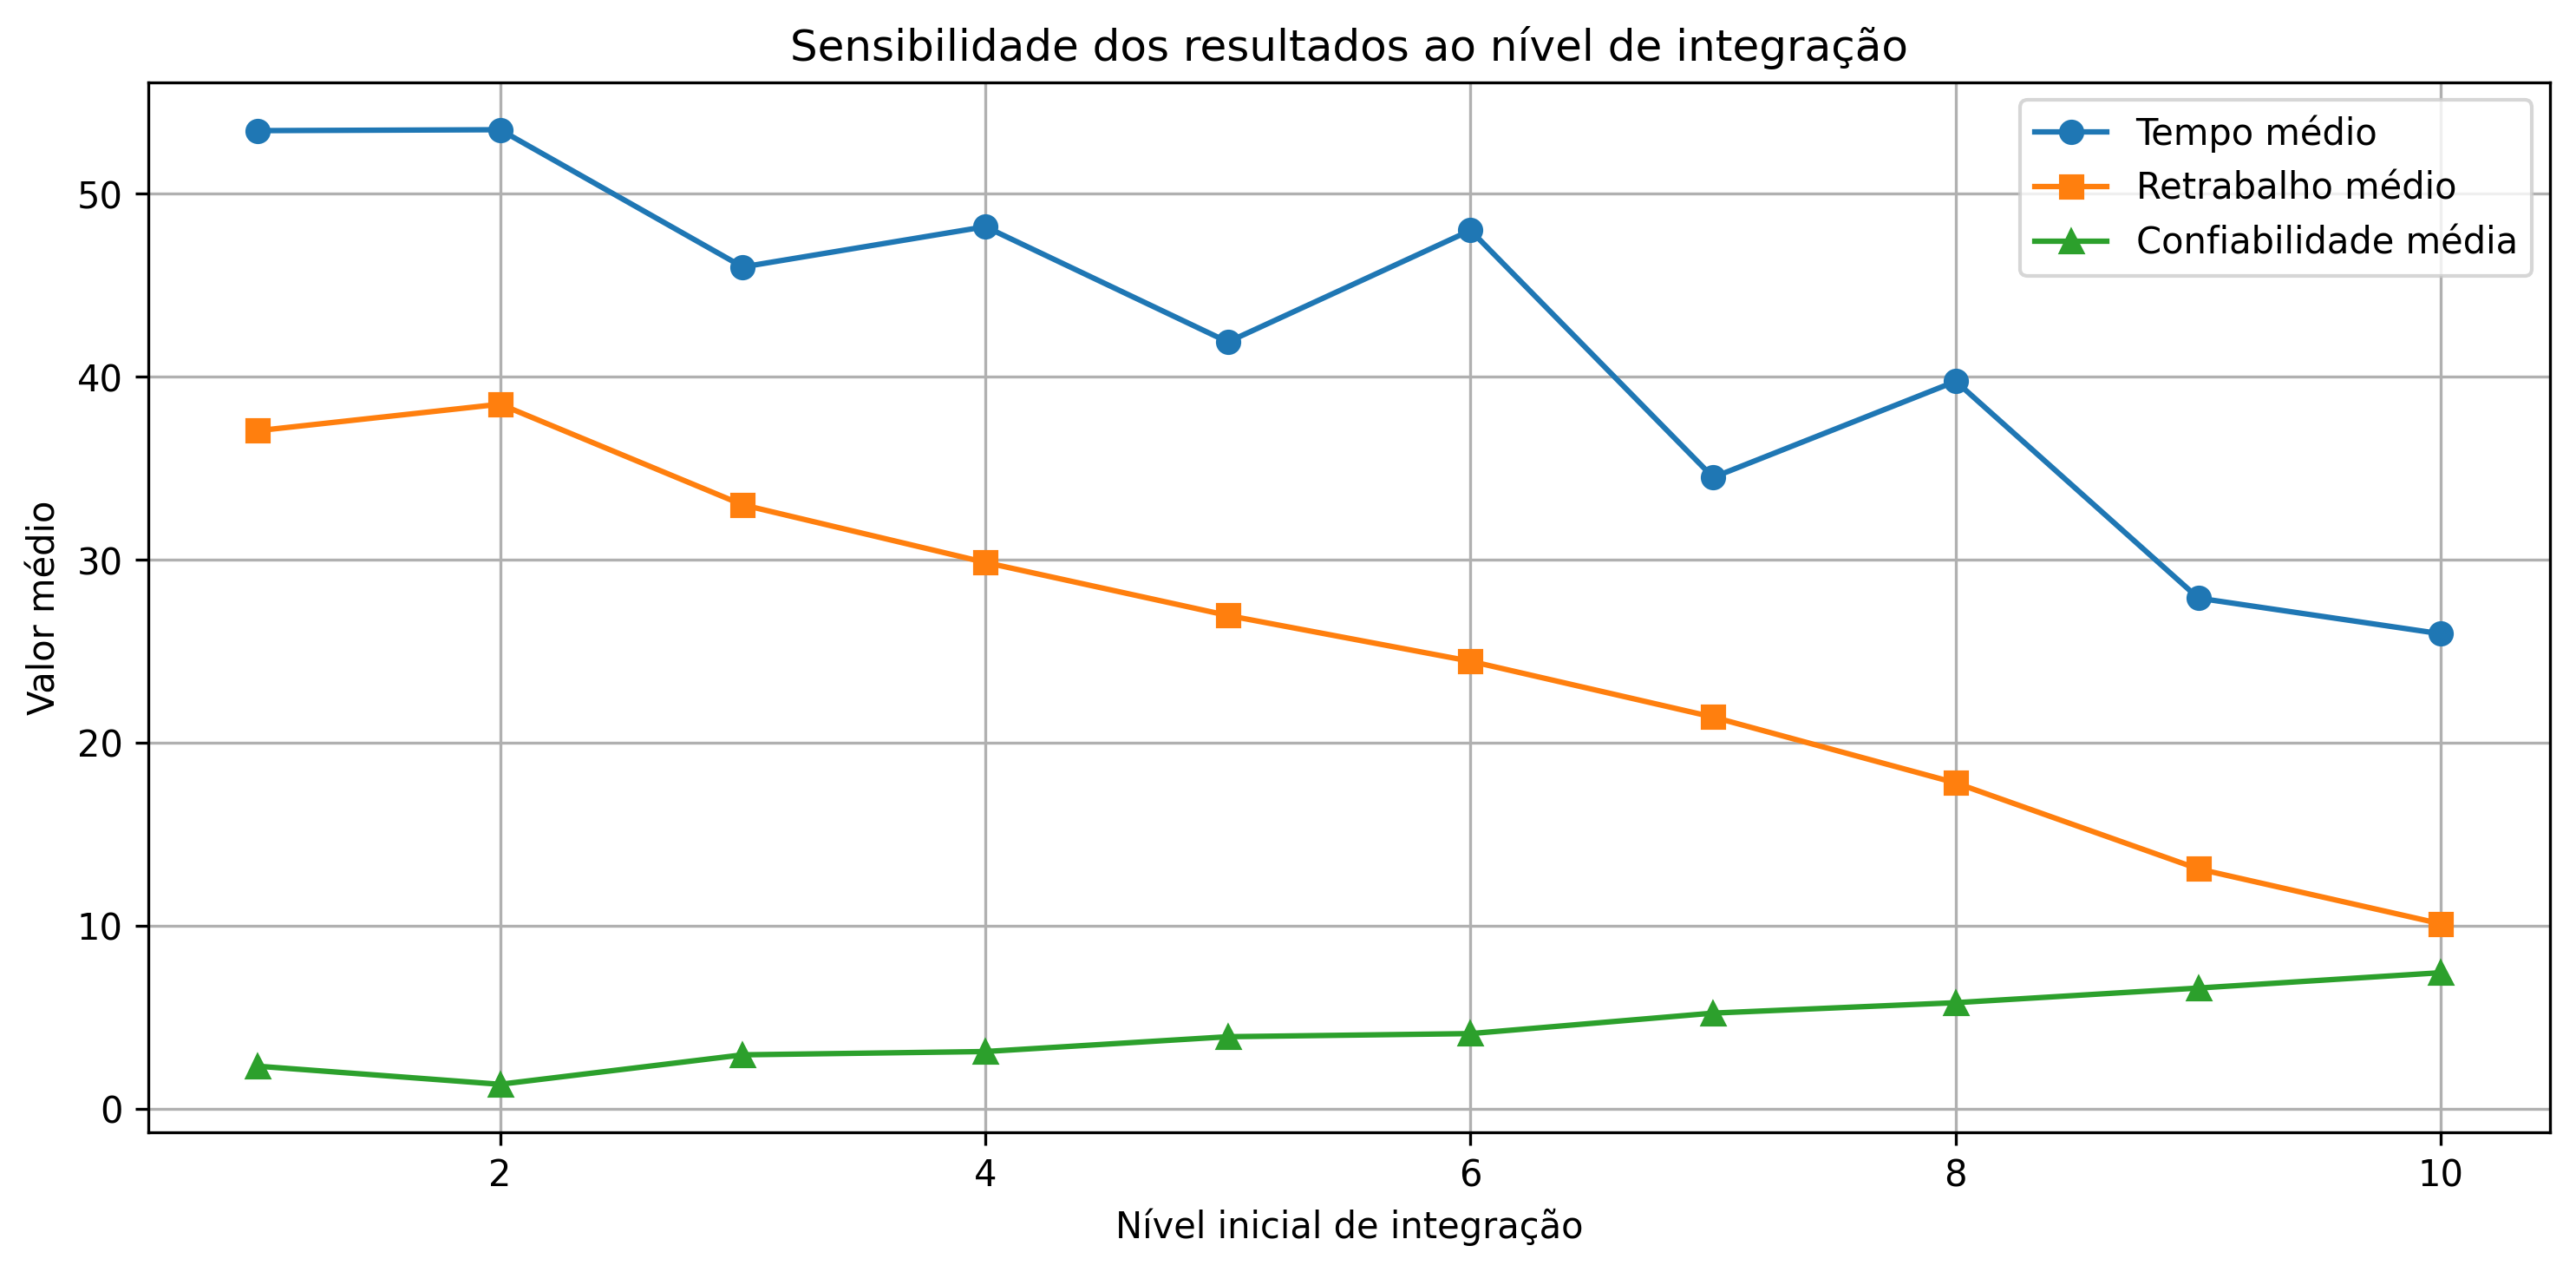


=== TESTE 4: SENSIBILIDADE DO ATRASO ===
   atraso_inicial  tempo_medio  retrabalho_medio  confiabilidade_media
0               1        26.30             14.70                  6.19
1               2        28.00             14.30                  6.37
2               3        33.65             19.00                  5.36
3               4        30.15             15.70                  6.09
4               5        46.25             18.55                  5.57
5               6        45.10             18.80                  5.45
6               7        44.70             14.40                  6.58
7               8        47.20             15.75                  6.03
8               9        47.15             14.90                  6.38
9              10        52.00             15.25                  6.26


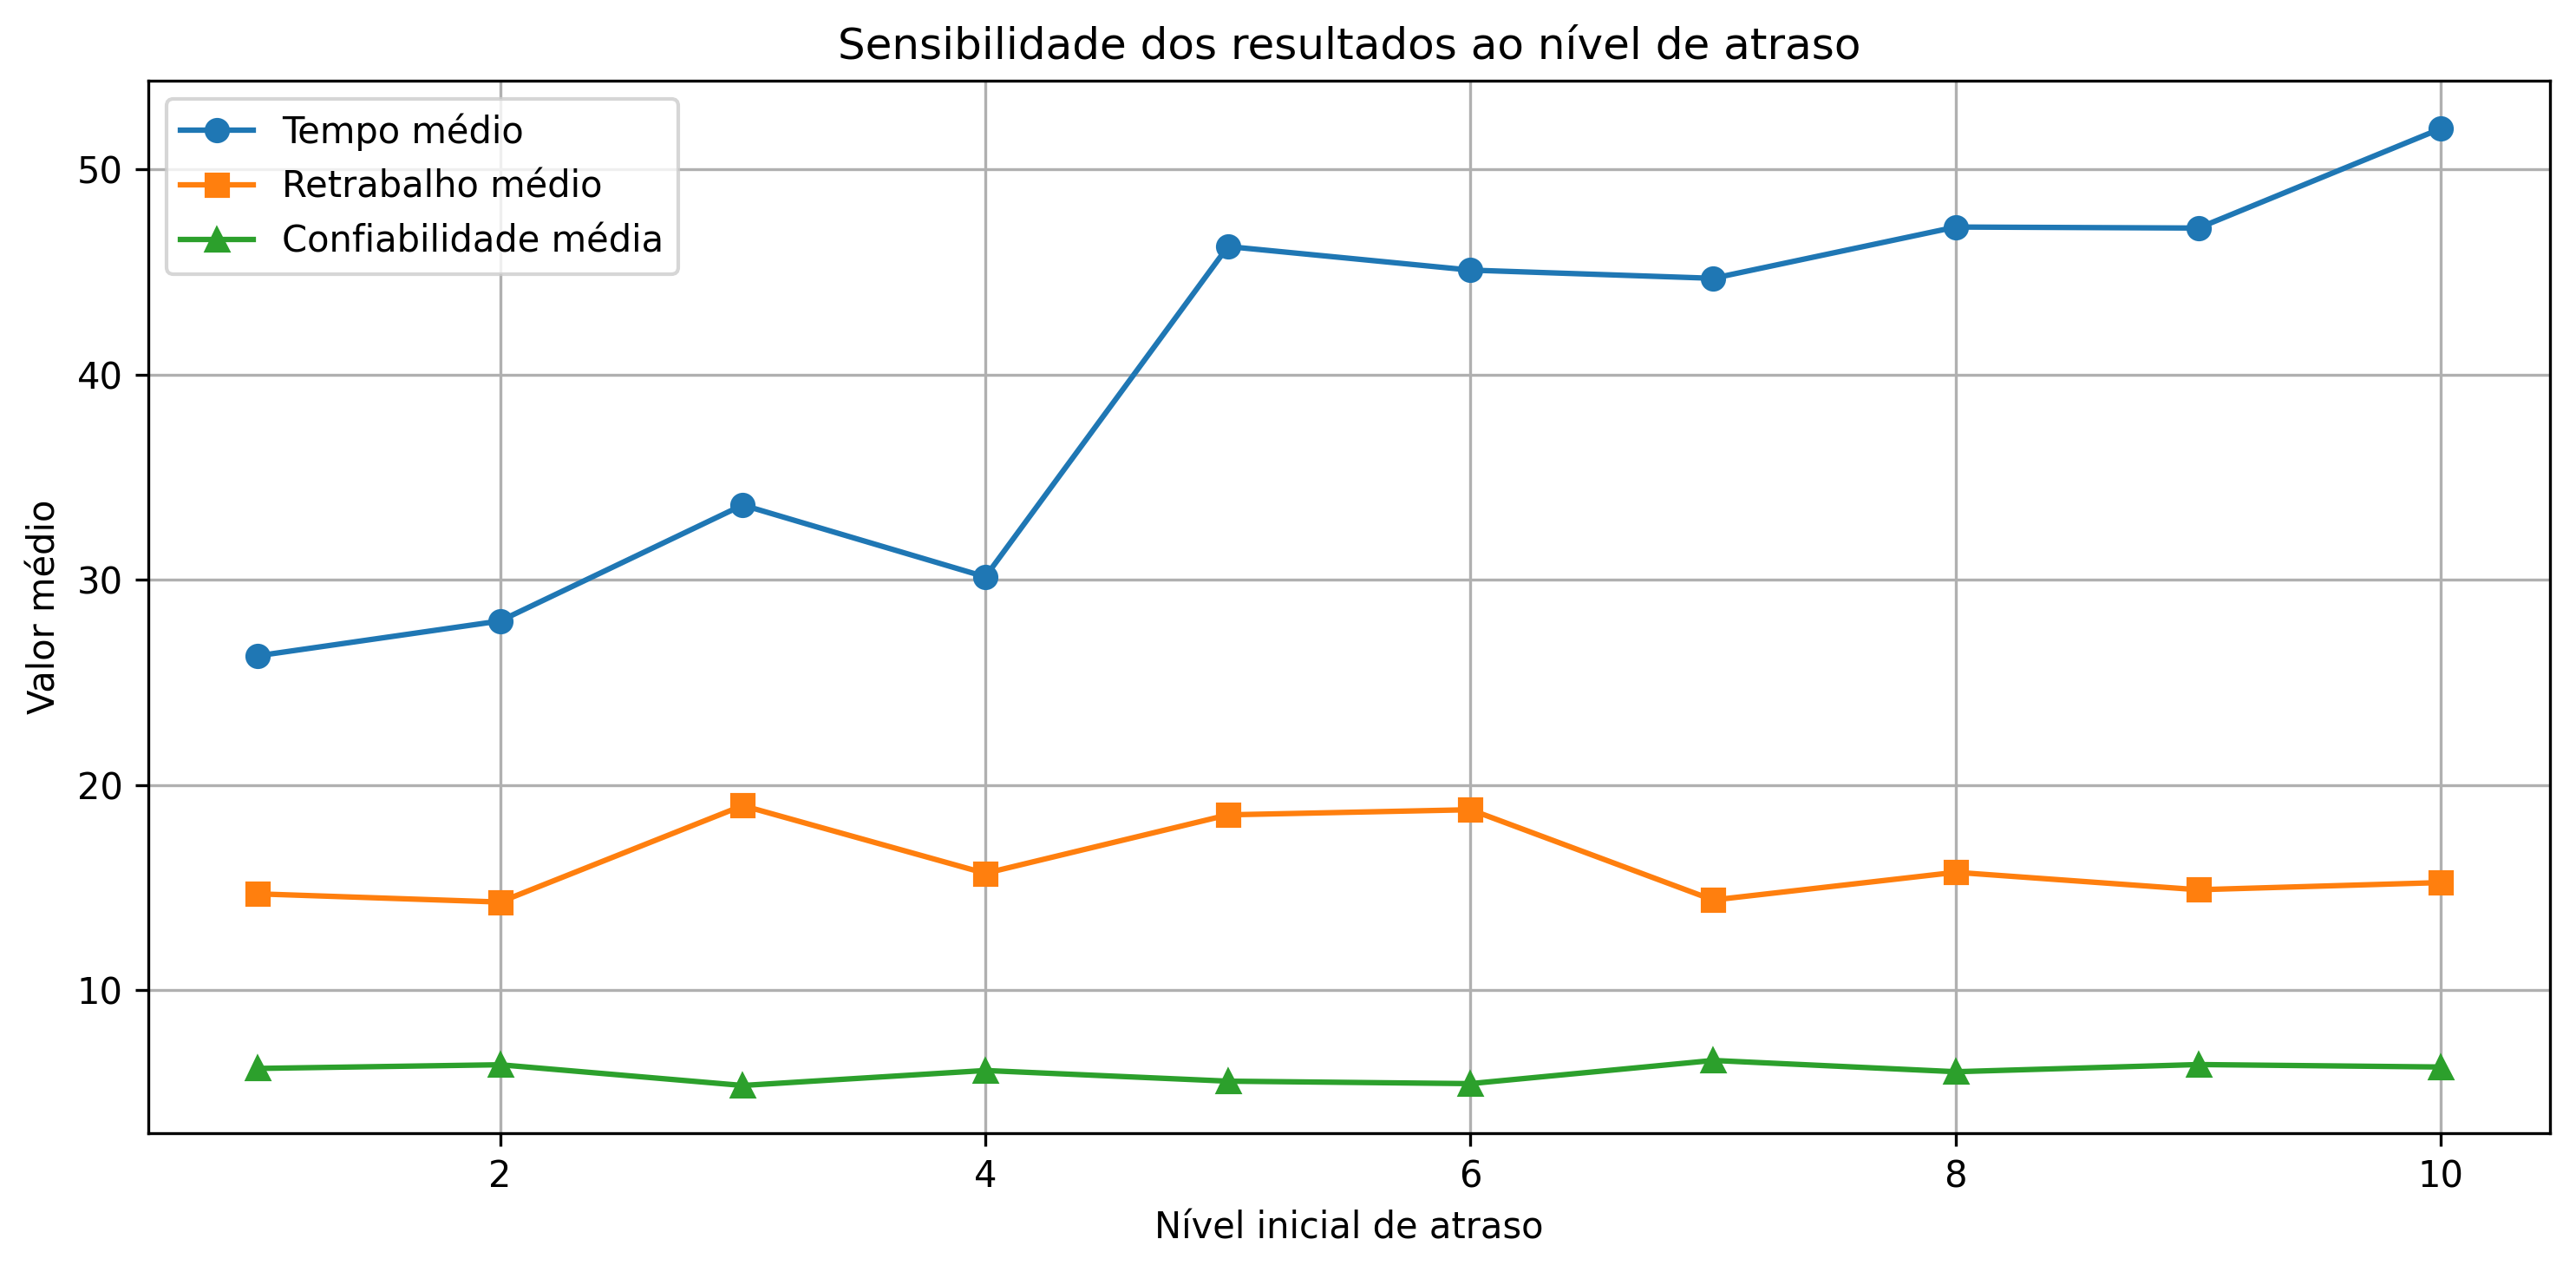


--- Comparação de Cenários ---

Cenário: baixa_integracao
Tempo médio de fechamento: 65.00
Retrabalho médio: 42.10
Confiabilidade média: 0.76

Cenário: alta_integracao
Tempo médio de fechamento: 40.20
Retrabalho médio: 22.45
Confiabilidade média: 4.83

Cenário: atrasos_frequentes
Tempo médio de fechamento: 67.70
Retrabalho médio: 34.05
Confiabilidade média: 2.13

Cenário: melhor_colaboracao
Tempo médio de fechamento: 38.95
Retrabalho médio: 21.20
Confiabilidade média: 5.21


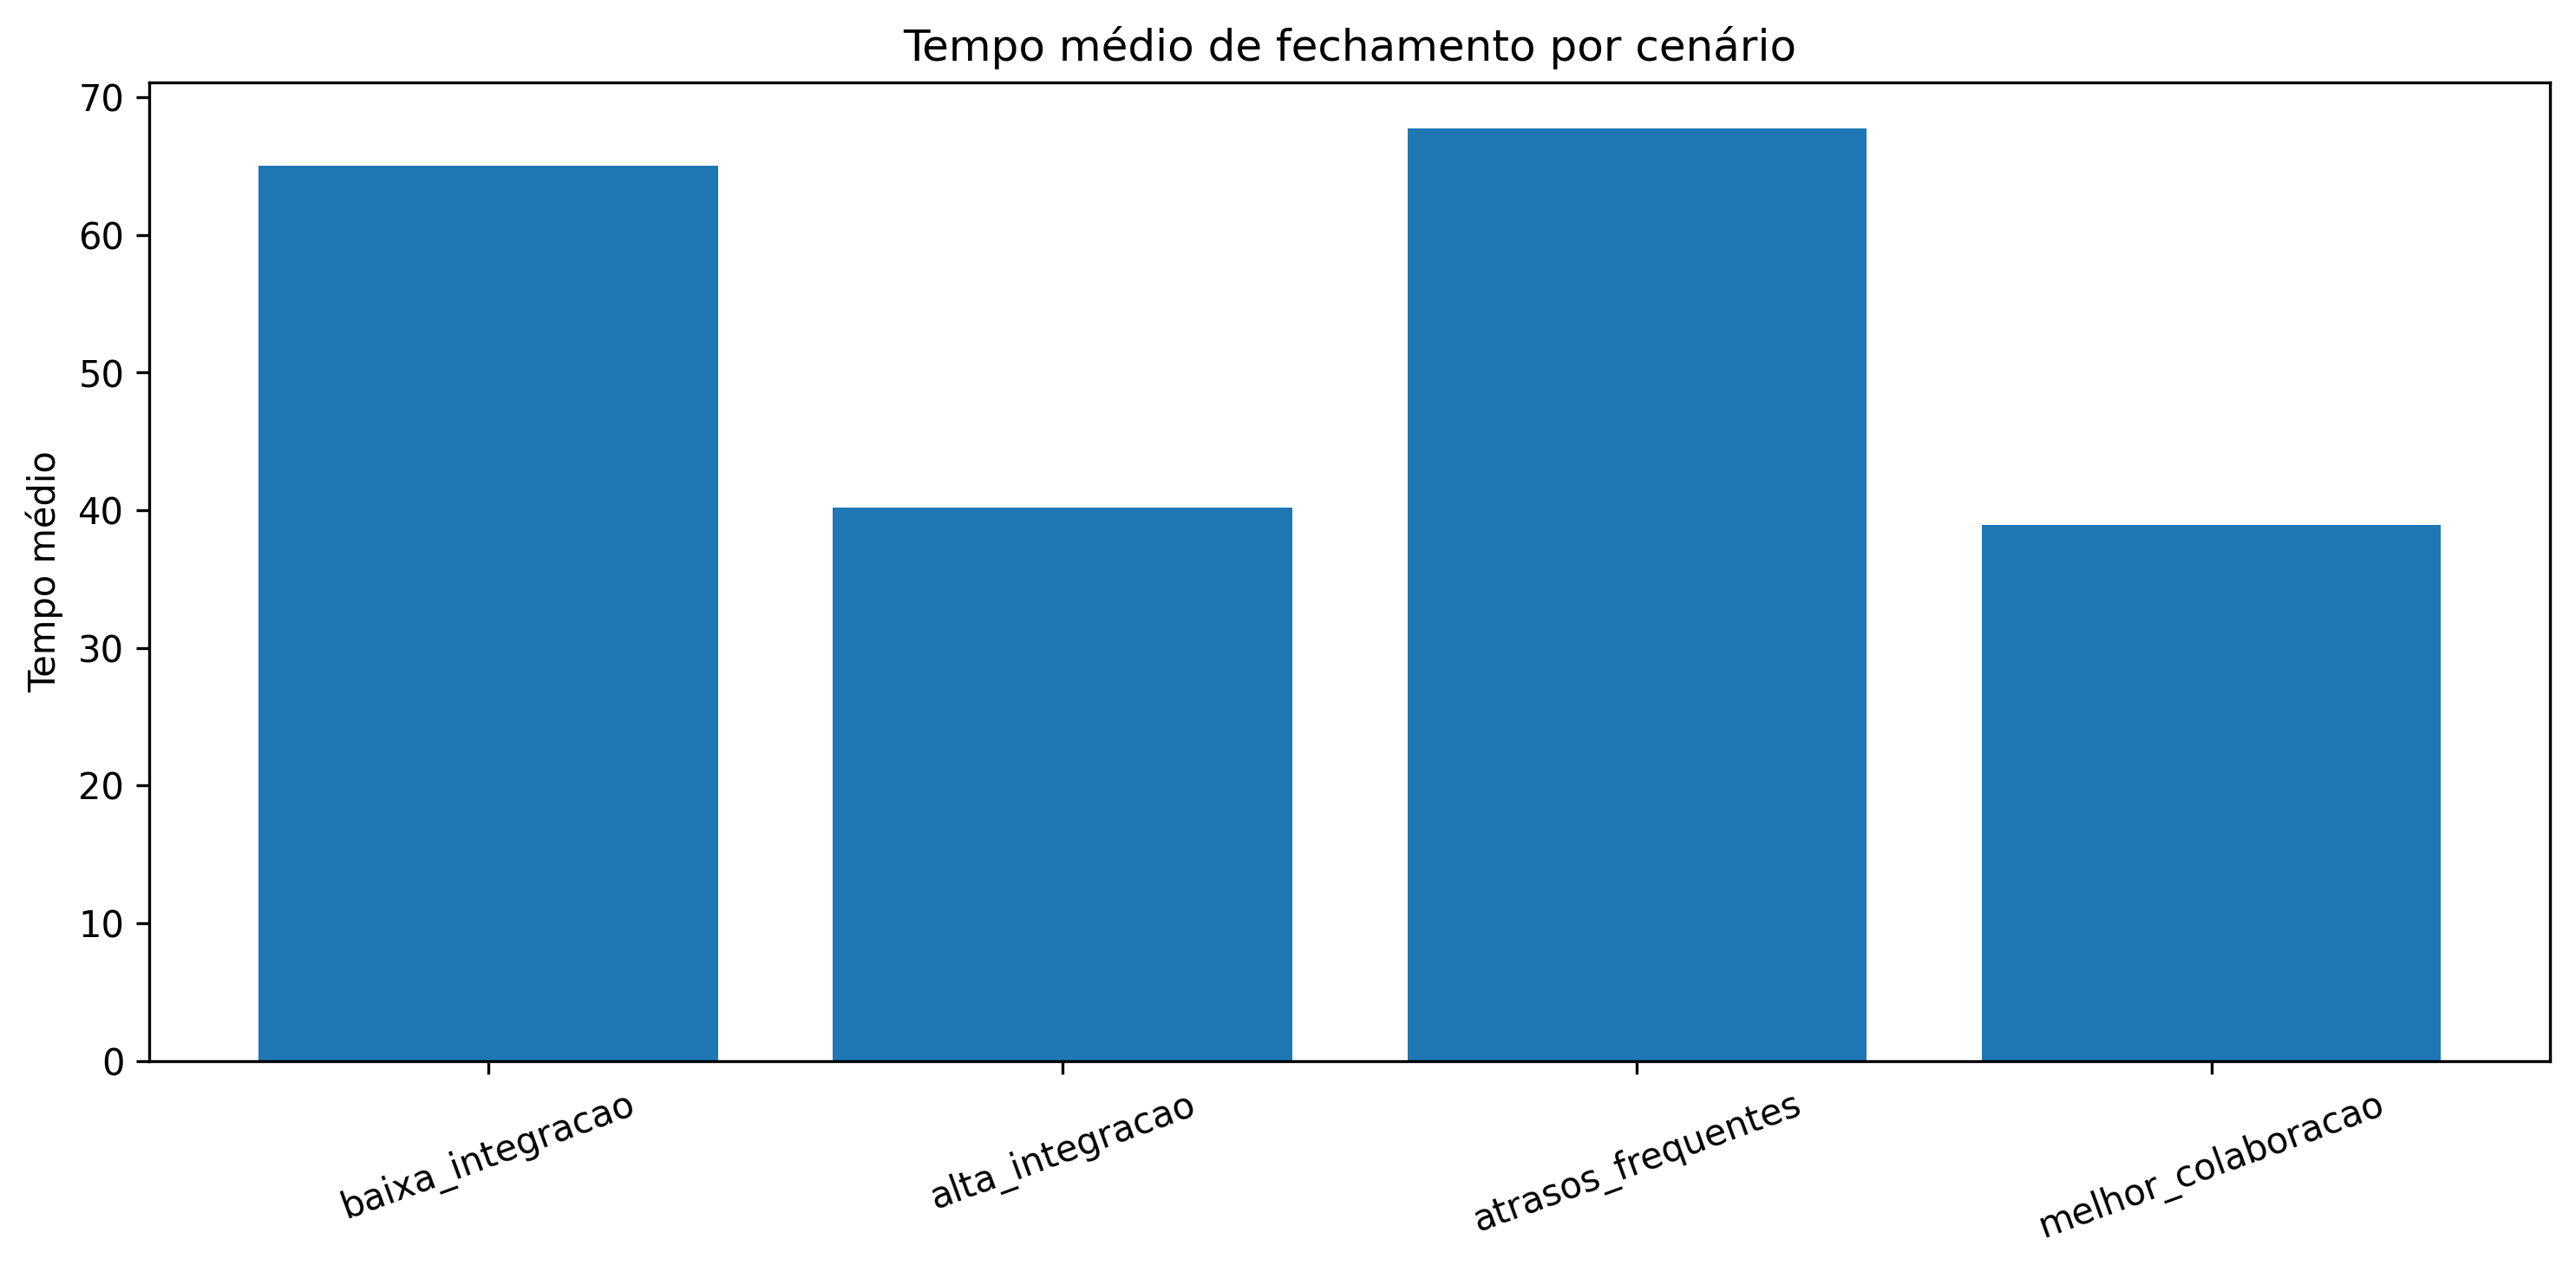

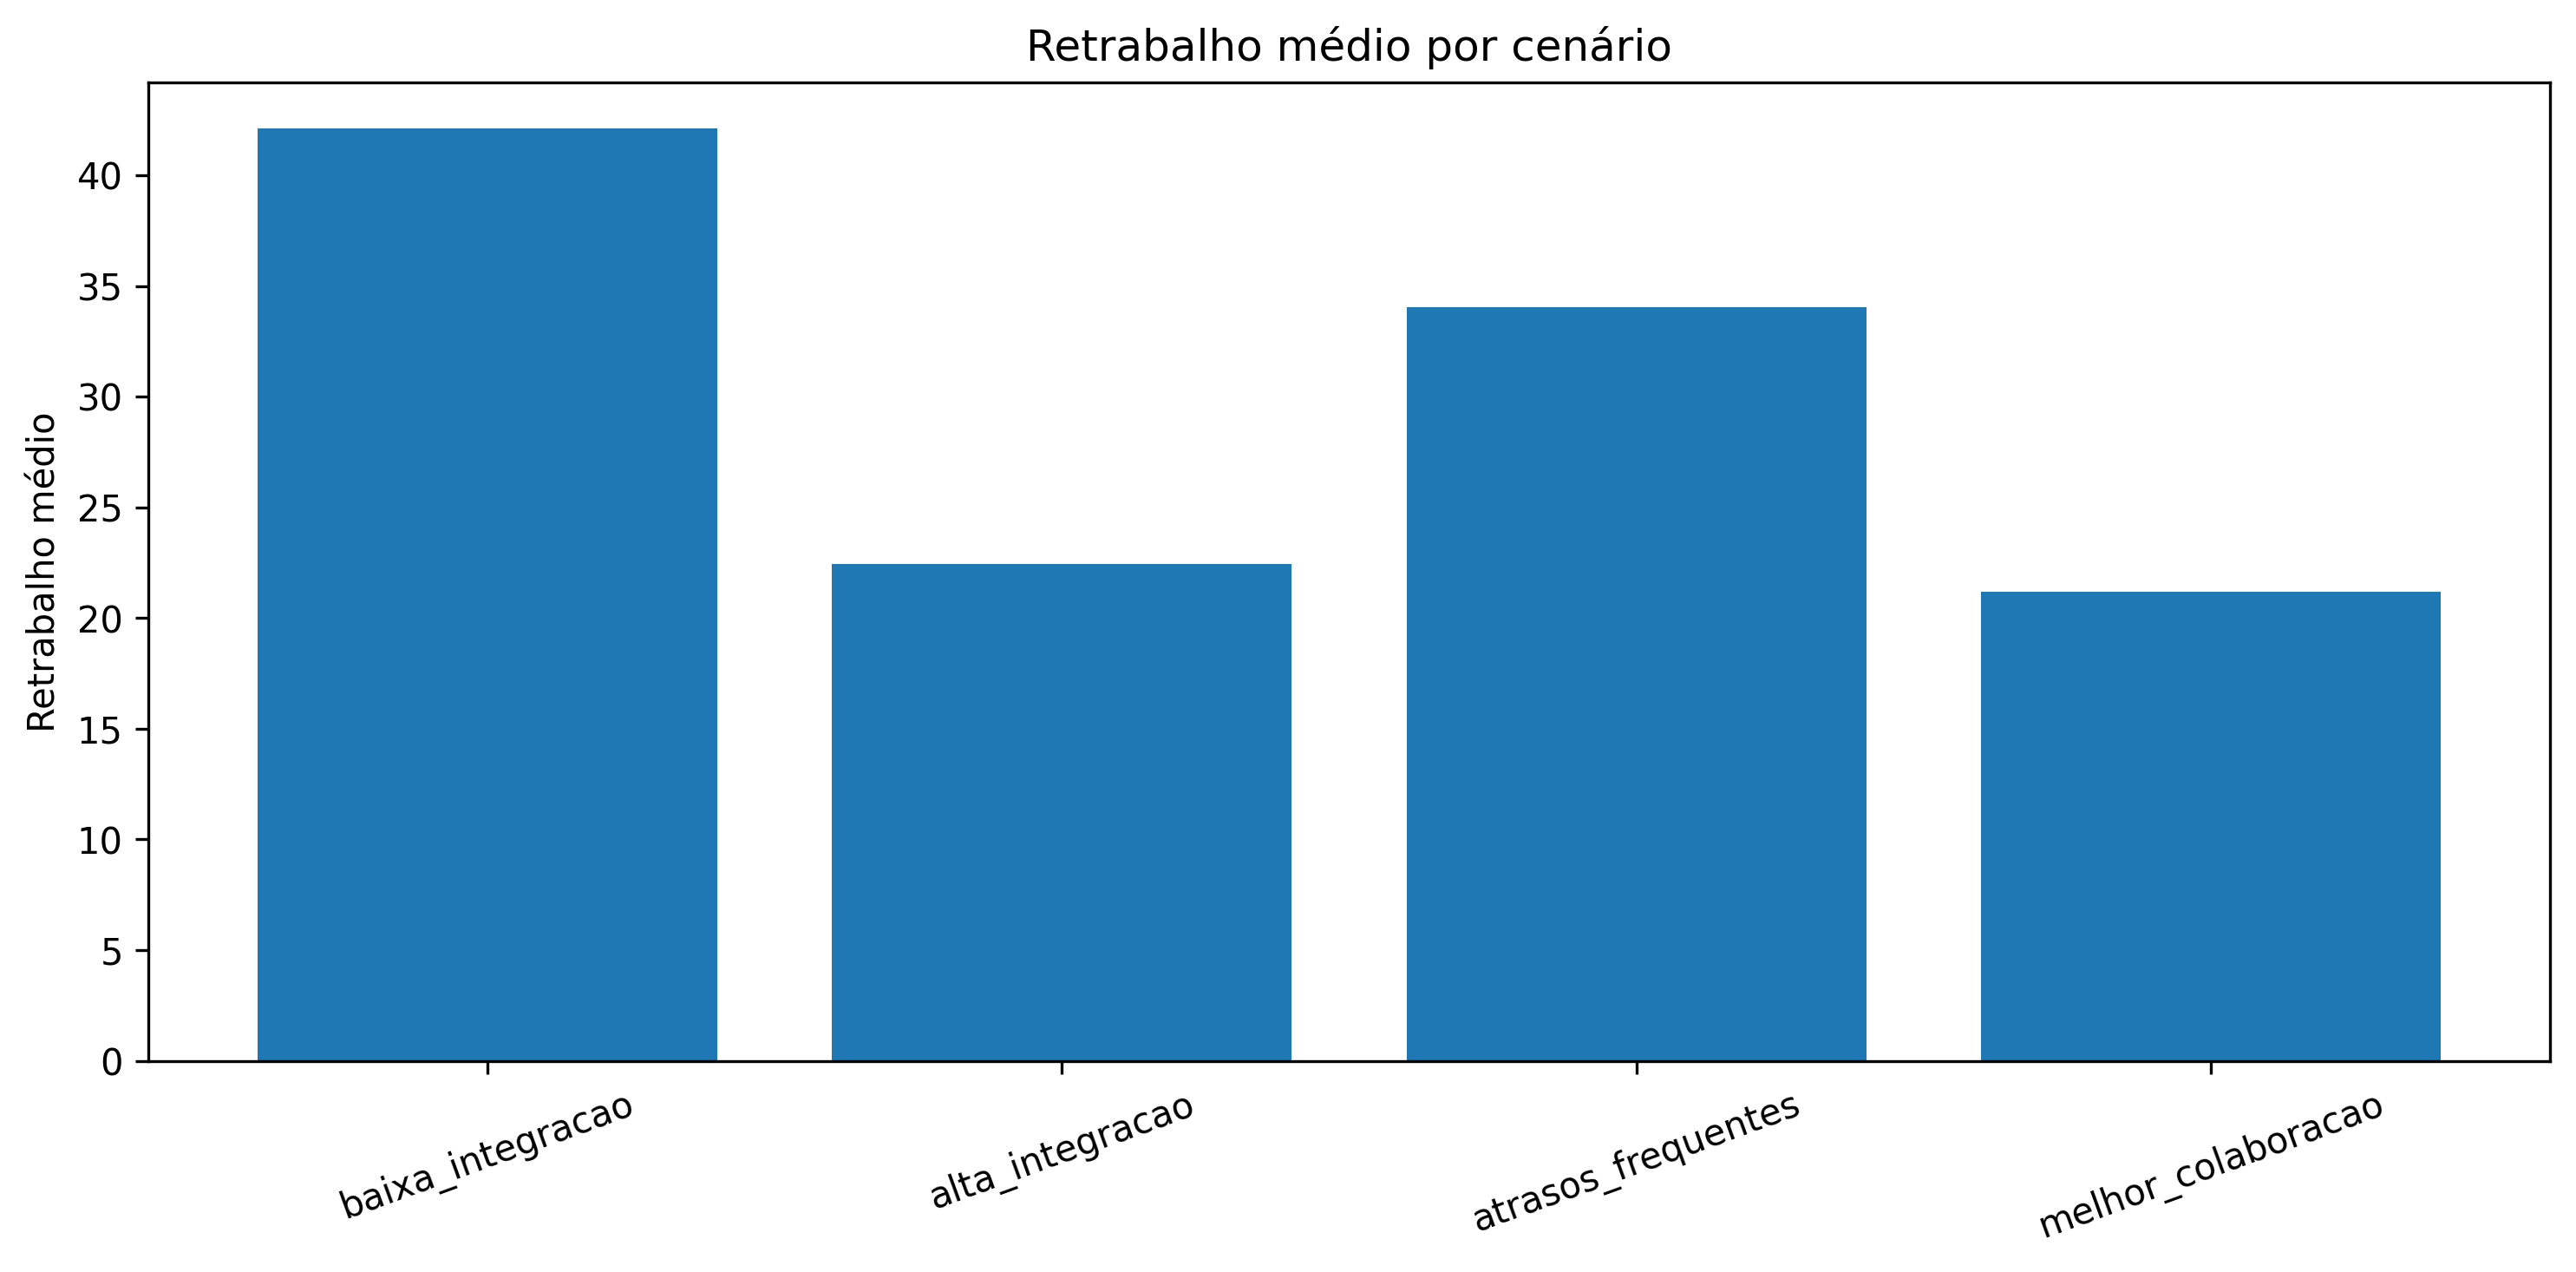

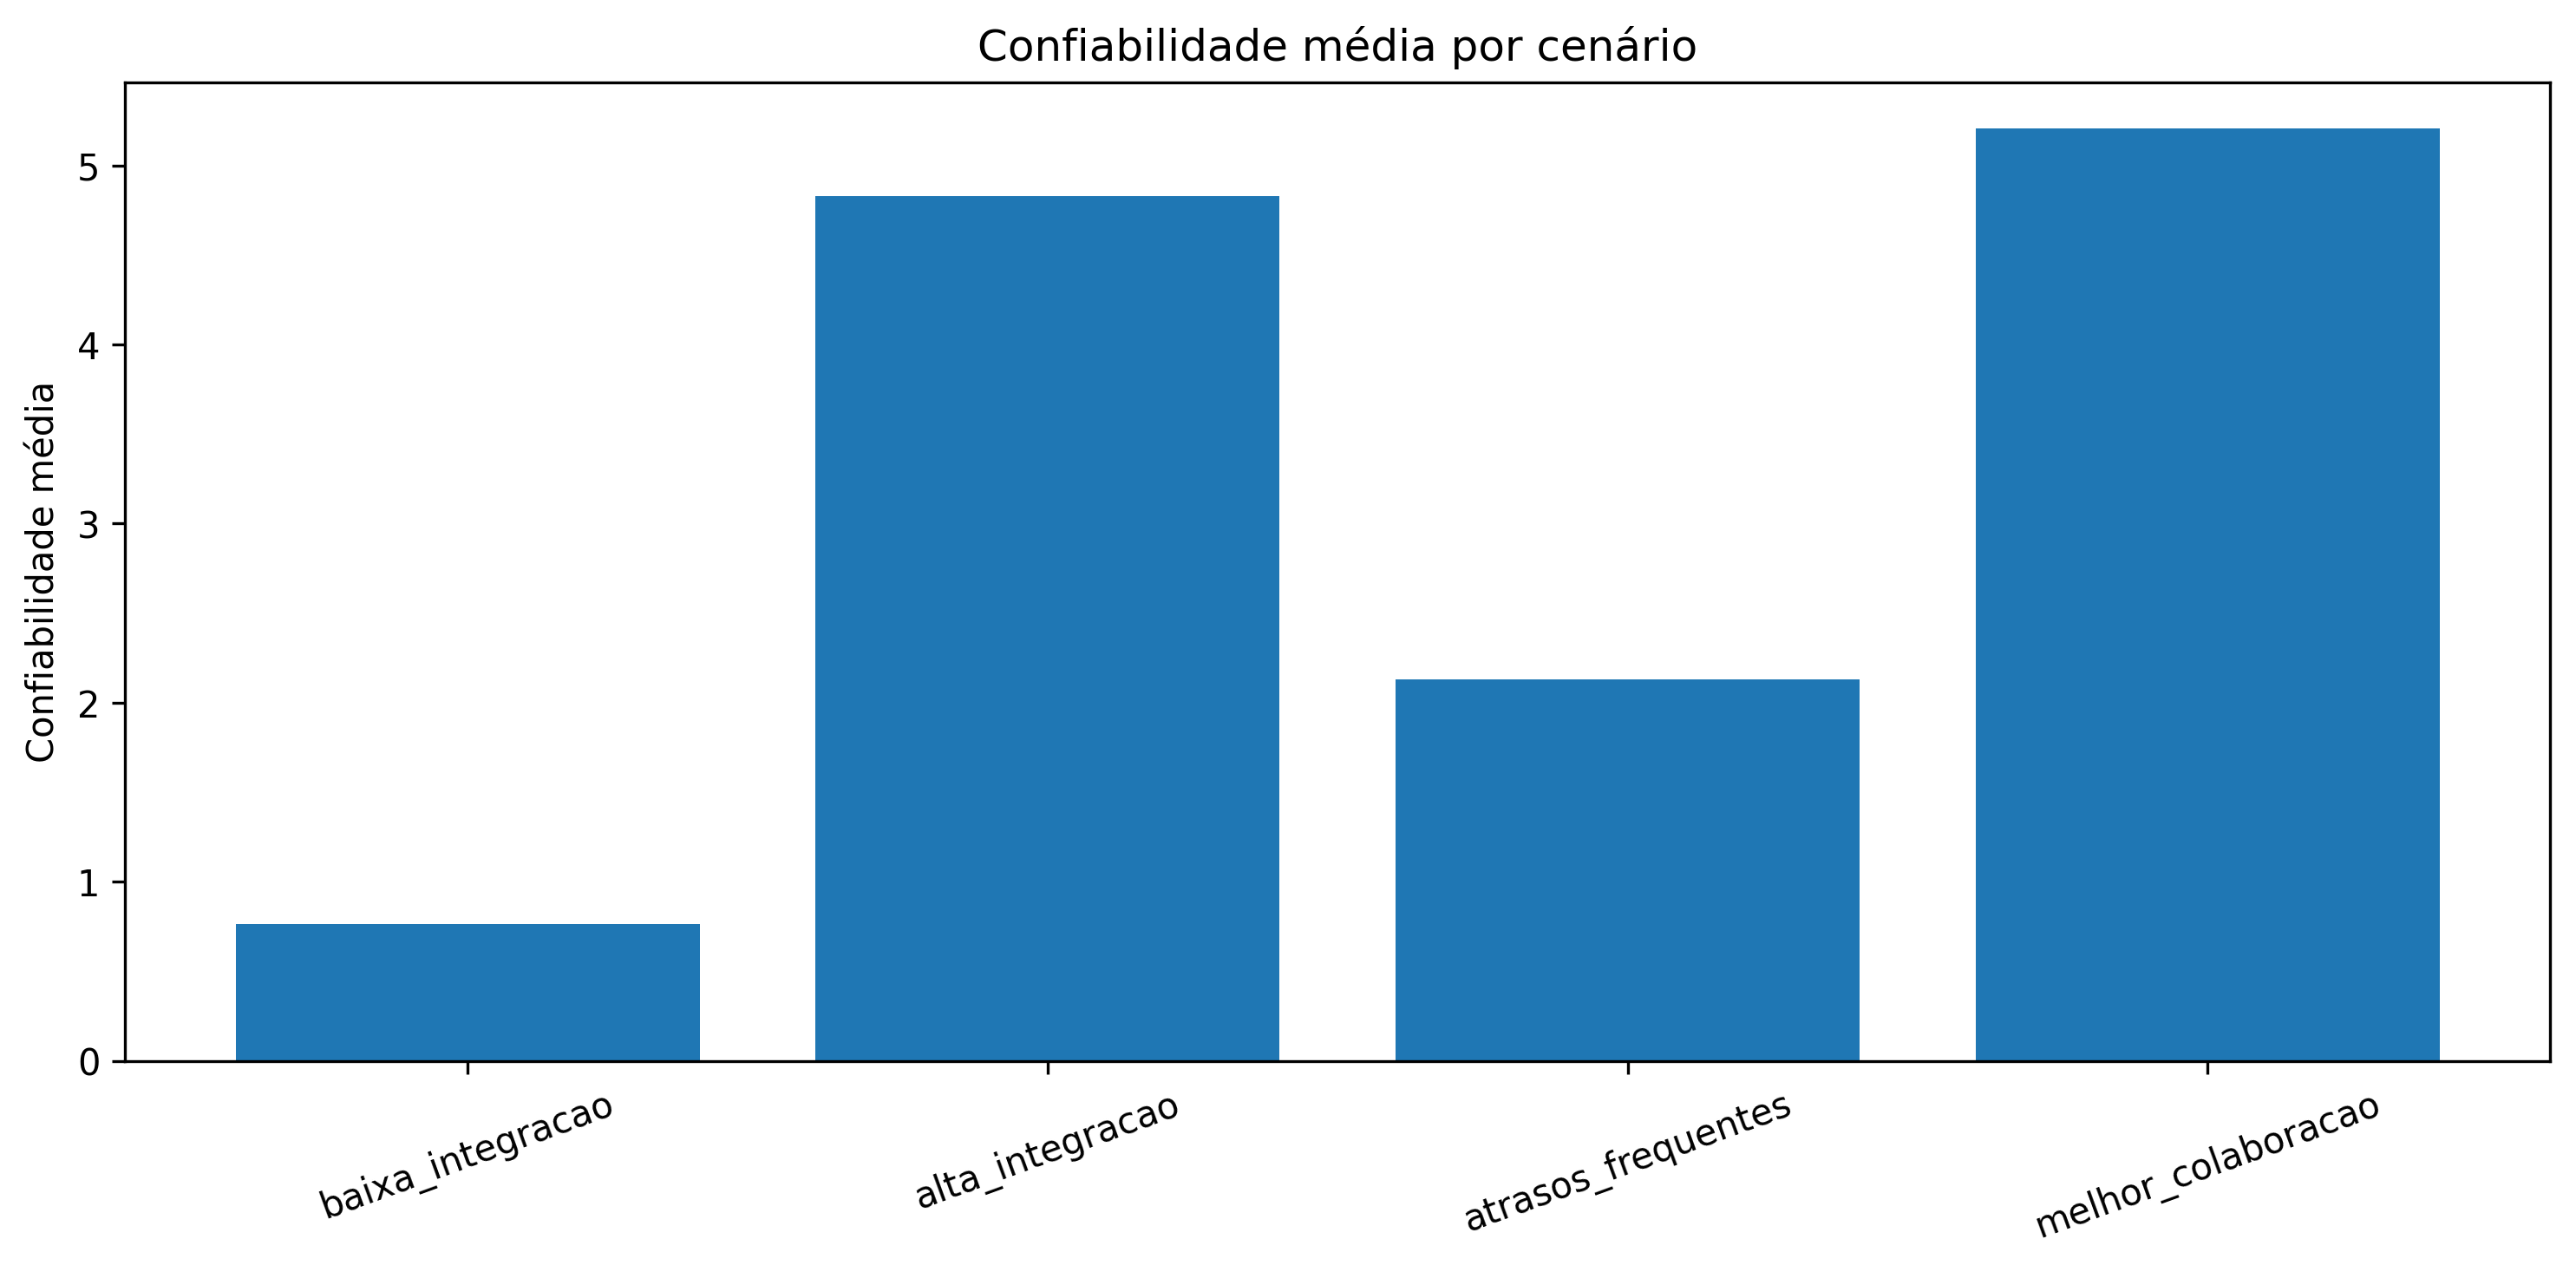


Testes concluídos.


In [ ]:
print("Iniciando testes...")

cenarios = [
    "baixa_integracao",
    "alta_integracao",
    "atrasos_frequentes",
    "melhor_colaboracao"
]

# Teste 1
df_cenarios = teste_comparacao_cenarios(cenarios, ciclos=20)

# Teste 2
df_repeticao = teste_repeticao_cenario("baixa_integracao", n_execucoes=30, ciclos=20)

# Teste 3
df_integracao = testar_sensibilidade_integracao(ciclos=20)

# Teste 4
df_atraso = testar_sensibilidade_atraso(ciclos=20)

# Gráficos comparativos principais
comparar_medias(cenarios, ciclos=20)

print("\nTestes concluídos.")

In [ ]:
df_cenarios.to_csv("resultados_cenarios.csv", index=False)
df_repeticao.to_csv("resultados_repeticao.csv", index=False)
df_integracao.to_csv("resultados_sensibilidade_integracao.csv", index=False)
df_atraso.to_csv("resultados_sensibilidade_atraso.csv", index=False)

print("Arquivos CSV salvos com sucesso.")

Arquivos CSV salvos com sucesso.
